# Iterated Prisoner's Dilemma: Game Theory Analysis & Tournament

**Author:** Momchil Ivanov  
**Course:** Math Concepts for Developers  
**Date:** March 2026

---

## 1. Introduction

### 1.1 The Cooperation Dilemma

Cooperation is fundamental to human society, biological systems, and economic interactions. Yet from an individual perspective, cooperation often appears irrational. Why should organisms cooperate when selfish behavior might yield immediate benefits?

Without cooperation, progress is impossible. Scientific advancement requires shared knowledge, economic development depends on trust and exchange, and social stability relies on mutual support. Yet cooperation creates an asymmetry problem: when only one side cooperates (or cooperates most of the time), we face questionable ethics and exploitation. The cooperator bears costs while the defector reaps benefits - a fundamentally unfair and unsustainable dynamic.

This fundamental question appears across many domains:

**In Business:**
- Should competing pharmaceutical companies share clinical trial data?
- Should firms cooperate on industry standards or compete independently?

**In International Relations:**
- Nuclear disarmament: each nation benefits if others disarm, but keeping weapons provides security
- Climate change agreements: reducing emissions benefits everyone, but has individual costs

**In Healthcare:**
- Data sharing between research institutions
- Generic vs brand-name drug pricing strategies
- Antibiotic prescription practices (overuse harms collective good)

**In Biology:**
- Reciprocal altruism in animals (e.g., vampire bats sharing blood, grooming in primates)
- Symbiotic relationships between species (e.g., cleaner fish removing parasites from larger fish)
- Cooperative hunting and resource sharing (e.g., wolves hunting in packs, lions sharing kills)

The **Prisoner's Dilemma** is the canonical model in game theory that captures this tension between individual rationality and collective welfare.

### 1.2 The Classic Prisoner's Dilemma Story

Two suspects are arrested for a crime and interrogated separately. The prosecutor lacks sufficient evidence for a major conviction but offers each suspect the same deal:

- If you **testify against your partner** (defect) while they **remain silent** (cooperate), you go free and they serve 10 years
- If you both **remain silent** (cooperate), you both serve 1 year on a minor charge
- If you both **testify against each other** (defect), you both serve 5 years

Each prisoner faces a dilemma:
- Cooperation (silence) could lead to the best mutual outcome (1 year each)
- But defection (testimony) is individually rational regardless of partner's choice
- Individual rationality leads to mutual defection and 5 years each

This is the essence of the **social dilemma**: what's rational individually leads to collective irrationality.

#### Key Terms

Throughout this analysis, we use standard game theory terminology:

- **Cooperate (C)**: An action that benefits both players but requires paying a personal cost. In the prisoner story, this means remaining silent. More generally, it represents acting in the collective interest (e.g., sharing data, keeping agreements, trusting others).

- **Defect (D)**: An action that benefits oneself at the expense of the other player. In the prisoner story, this means testifying against your partner. More generally, it represents acting in pure self-interest (e.g., withholding information, breaking agreements, exploiting trust).

- **Cooperator**: A player or strategy that chooses to cooperate (C).

- **Defector**: A player or strategy that chooses to defect (D).

When we say "the cooperator bears costs while the defector reaps benefits," we refer to the asymmetric outcome where one player cooperates (C) while the other defects (D), resulting in the cooperator receiving the worst payoff (sucker's payoff) and the defector receiving the best (temptation payoff).

### 1.3 Project Objectives

This project investigates cooperation through three interconnected approaches:

**1. Mathematical Analysis**
- Formalize the Prisoner's Dilemma using game theory
- Prove that mutual defection is the Nash equilibrium
- Explain why iteration changes everything
- Introduce evolutionary game theory concepts

**2. Computational Implementation**
- Implement 19 distinct strategies as Python classes
- Build a tournament engine for strategy competitions
- Create an evolutionary simulation system
- Develop comprehensive analysis and visualization tools

**3. Empirical Investigation**
- Run round-robin tournaments to identify successful strategies
- Analyze which strategies survive in evolutionary dynamics
- Examine the relationship between cooperation and success
- Draw insights about cooperation mechanisms

### 1.4 Research Questions

This analysis aims to answer:

1. **Which strategies succeed in tournaments?** We hypothesize that reciprocal strategies like Tit-for-Tat will rank highly.

2. **What balance of nice, retaliatory, and forgiving behaviors is optimal?** We expect pure strategies (Always Cooperate, Always Defect) to underperform.

3. **How does cooperation evolve over generations?** We hypothesize that cooperative strategies will dominate despite defection being individually rational.

4. **Is there a correlation between cooperation rate and tournament success?** We expect a non-linear relationship.

By combining rigorous mathematics with computational experiments, we'll understand not just *that* cooperation emerges, but *why* and *under what conditions*.

## 2. Mathematical Background

### 2.1 Game Theory Fundamentals

#### Definition 1: Normal-Form Game

A **normal-form game** is a tuple $(N, A, u)$ where:

- $N = \{1, 2, ..., n\}$ is a finite set of **players**
- $A = A_1 \times A_2 \times ... \times A_n$ is the set of **action profiles**, where $A_i$ is the set of actions available to player $i$
- $u = (u_1, u_2, ..., u_n)$ is the **utility profile**, where $u_i: A \rightarrow \mathbb{R}$ is player $i$'s payoff function

In a two-player game, each combination of actions $(a_1, a_2) \in A_1 \times A_2$ results in payoffs $(u_1(a_1, a_2), u_2(a_1, a_2))$.

#### Definition 2: Strategy

A **pure strategy** for player $i$ is a specific action $a_i \in A_i$. A **mixed strategy** is a probability distribution over actions.

In the context of the Prisoner's Dilemma, we focus on pure strategies: Cooperate (C) or Defect (D).

### 2.2 The Prisoner's Dilemma

#### The Payoff Matrix

The Prisoner's Dilemma is a two-player simultaneous game where each player chooses from $A = \{C, D\}$ (Cooperate or Defect). The payoff matrix is:

$$
\begin{array}{c|c|c}
 & C & D \\
\hline
C & (R, R) & (S, T) \\
\hline
D & (T, S) & (P, P) \\
\end{array}
$$

where payoffs are interpreted as:

- $T$ = **Temptation** to defect (you defect while opponent cooperates)
- $R$ = **Reward** for mutual cooperation
- $P$ = **Punishment** for mutual defection
- $S$ = **Sucker's payoff** (you cooperate while opponent defects)

#### Defining Constraints

For this to constitute a valid Prisoner's Dilemma, we require:

$$T > R > P > S$$

This ensures that:
1. Defecting against a cooperator is best ($T > R$)
2. Mutual cooperation beats mutual defection ($R > P$)
3. Mutual defection beats being exploited ($P > S$)

Additionally, to prevent alternating D and C from being optimal:

$$2R > T + S$$

This ensures mutual cooperation is better than alternating exploitation.

#### Standard Payoff Values

We use the common convention:
- $T = 5$ (temptation)
- $R = 3$ (reward)
- $P = 1$ (punishment)
- $S = 0$ (sucker)

Verification: $5 > 3 > 1 > 0$ and $2(3) = 6 > 5 + 0 = 5$

#### Definition 3: Nash Equilibrium

**Intuitive Idea:**  
A Nash equilibrium is a situation where no player can improve their outcome by changing their decision alone, while others keep their choices fixed. In other words: each player is already doing the best for themselves, given what others are doing.

**Formal Definition:**

A strategy profile $a^* = (a_1^*, a_2^*, ..., a_n^*)$ is a **Nash equilibrium** if:

$$u_i(a_i^*, a_{-i}^*) \geq u_i(a_i, a_{-i}^*) \quad \forall i \in N, \forall a_i \in A_i$$

**Notation explained:**
- $a_i^*$ = optimal action of player $i$ (part of equilibrium)
- $a_{-i}^*$ = actions of all other players except $i$
- $u_i(a_i^*, a_{-i}^*)$ = my payoff if I play the optimal action
- $u_i(a_i, a_{-i}^*)$ = my payoff if I deviate to some other action $a_i$
- The condition says: the optimal action gives at least as good a payoff as any alternative

**Example for Prisoner's Dilemma:**

Let's verify that $(D, D)$ is a Nash equilibrium using the payoff matrix we'll see shortly (where T=5, R=3, P=1, S=0):

*Player 1's perspective:*
- If I play $D$ while Player 2 plays $D$: I get 1 point
- If I switch to $C$ while Player 2 plays $D$: I get 0 points
- Since $1 > 0$, I have no incentive to switch

*Player 2's perspective:*
- Same logic: no incentive to switch

**Conclusion:** Neither player can improve unilaterally, so $(D, D)$ is Nash equilibrium. This is the tragedy: both would prefer $(C, C)$ which gives 3 points each, but rational individual optimization traps them at $(D, D)$.

#### Definition 4: Dominant Strategy

**Intuitive Idea:**  
A dominant strategy is one that gives you the best outcome **no matter what the other players do**. Unlike Nash equilibrium (which requires knowing what others will play), a dominant strategy is optimal against any possible opponent action.

**Formal Definition:**

Strategy $a_i^*$ **strictly dominates** strategy $a_i$ for player $i$ if:

$$u_i(a_i^*, a_{-i}) > u_i(a_i, a_{-i}) \quad \forall a_{-i} \in A_{-i}$$

**Notation explained:**
- $a_i^*$ = the dominant strategy for player $i$
- $a_i$ = any alternative strategy player $i$ could choose
- $a_{-i}$ = actions of all other players (except player $i$)
- $A_{-i}$ = set of all possible action combinations by other players
- $u_i(a_i^*, a_{-i})$ = my payoff if I play the dominant strategy
- $u_i(a_i, a_{-i})$ = my payoff if I play an alternative strategy
- $>$ = strictly greater (not just equal, but actually better)
- $\forall a_{-i} \in A_{-i}$ = "for all possible actions by opponents" (no matter what they do)

**Example for Prisoner's Dilemma:**

Let's verify that $D$ (Defect) is a strictly dominant strategy:

*Case 1: Opponent plays C (Cooperate):*
- If I play $D$: I get $T = 5$ points
- If I play $C$: I get $R = 3$ points
- Since $5 > 3$, playing $D$ is better

*Case 2: Opponent plays D (Defect):*
- If I play $D$: I get $P = 1$ point
- If I play $C$: I get $S = 0$ points
- Since $1 > 0$, playing $D$ is better

**Conclusion:** $D$ performs better in **both cases**, regardless of opponent's choice. Therefore, $D$ strictly dominates $C$.

**The Tragedy:** Both players have $D$ as their dominant strategy, so rational players will both defect and end up at $(D, D)$ with 1 point each. If they had both cooperated at $(C, C)$, they would have gotten 3 points each - but cooperation is not rational in the one-shot game!

### 2.3 Theoretical Results for One-Shot Game

#### Theorem 1: Mutual Defection is Nash Equilibrium

**Statement**: In the one-shot Prisoner's Dilemma with $T > R > P > S$, the strategy profile $(D, D)$ is the unique Nash equilibrium in pure strategies.

**Proof**:

We must show that neither player can improve their payoff by unilaterally deviating from $(D, D)$.

*Case 1: Player 1's perspective (given Player 2 plays D)*
- If Player 1 plays $D$: payoff = $P$
- If Player 1 plays $C$: payoff = $S$
- Since $P > S$ by assumption, Player 1 cannot improve by deviating to $C$

*Case 2: Player 2's perspective (given Player 1 plays D)*
- If Player 2 plays $D$: payoff = $P$
- If Player 2 plays $C$: payoff = $S$
- Since $P > S$ by assumption, Player 2 cannot improve by deviating to $C$

Therefore, $(D, D)$ satisfies the Nash equilibrium condition: neither player can improve by unilateral deviation. $\square$

#### Theorem 2: Defection is a Dominant Strategy

**Statement**: In the one-shot Prisoner's Dilemma, $D$ strictly dominates $C$ for both players.

**Proof**:

We must show that $D$ yields higher payoff than $C$ regardless of opponent's action.

*If opponent plays C:*
- Playing $D$ gives payoff $T$
- Playing $C$ gives payoff $R$
- Since $T > R$ by assumption, $D$ is better

*If opponent plays D:*
- Playing $D$ gives payoff $P$
- Playing $C$ gives payoff $S$
- Since $P > S$ by assumption, $D$ is better

Since $D$ is better in all cases, it strictly dominates $C$. $\square$

**Corollary**: Since both players have a strictly dominant strategy, the unique Nash equilibrium is found by each player playing their dominant strategy: $(D, D)$.

#### The Social Dilemma

Despite $(D, D)$ being the Nash equilibrium with payoff $(P, P) = (1, 1)$, note that:

$$u_1(C, C) = u_2(C, C) = R = 3 > P = 1$$

Both players would be strictly better off cooperating, yet rational individual play leads to mutual defection. The Nash equilibrium is **Pareto inefficient** (an outcome is Pareto inefficient if there exists an alternative that makes at least one person better off without making anyone worse off - here, $(C, C)$ makes both players better off).

This captures the essence of many social dilemmas: individual rationality produces collectively suboptimal outcomes.

### 2.4 The Iterated Prisoner's Dilemma

#### Why Iteration Changes Everything

In a one-shot game, defection is unambiguously dominant. But what happens when the same players interact repeatedly?

**Definition 5: Iterated Prisoner's Dilemma**

The Prisoner's Dilemma game is repeated for $T$ rounds, where $T$ may be:

- **Known and finite:** Both players know the game will last exactly $T$ rounds (e.g., 100 rounds). Problem: backward induction applies - in the last round, players know there's no future, so they defect. This unravels cooperation from round $T$ back to round 1.

- **Unknown but finite:** The game ends probabilistically. After each round, there's probability $p$ of continuing (e.g., 90% chance of another round). Players don't know which round will be last, preventing backward induction. This is more realistic - most real relationships have uncertain duration.

- **Infinite (theoretical limit):** The game never ends ($T \to \infty$). This is mathematically convenient because it eliminates end-game effects entirely. While unrealistic, it captures situations where the continuation probability is very high ($p \to 1$).

Players observe all previous moves and can condition their current action on the complete history of play.

#### The Shadow of the Future

Iteration introduces a critical new element: **reputation and reciprocity**. Current actions affect future interactions, creating incentives for cooperation.

**Key insight**: If players value future payoffs sufficiently, the short-term gain from defection can be outweighed by the long-term cost of losing cooperation.

#### Discount Factor

Let $\delta \in [0, 1]$ be the **discount factor** representing how much players value future payoffs relative to current ones. The present value of an infinite stream of payoffs $\pi_1, \pi_2, \pi_3, ...$ is:

$$V = \sum_{t=1}^{\infty} \delta^{t-1} \pi_t = \pi_1 + \delta \pi_2 + \delta^2 \pi_3 + ...$$

When $\delta = 0$, only current payoff matters (equivalent to one-shot game).  
When $\delta = 1$, all future payoffs are valued equally.  
Typically $\delta \in (0, 1)$, representing that future is valued but less than present.

**Understanding $\delta$ intuitively:**
- **$\delta = 0.5$:** A payoff tomorrow is worth half of today's payoff. Next year's payoff is worth $0.5^{365}$ ≈ 0 (future barely matters).
- **$\delta = 0.9$:** Tomorrow's payoff is worth 90% of today's. In 10 rounds, payoffs are still worth $0.9^{10}$ ≈ 35% (future matters significantly).
- **$\delta = 0.99$:** Very patient players. Even 100 rounds ahead, payoffs are worth $0.99^{100}$ ≈ 37% (long-term thinking).

Higher $\delta$ means:
- More patient players
- Longer time horizons
- Stronger incentive to maintain cooperation
- Greater "shadow of the future"

#### Condition for Sustainable Cooperation

Consider a simple trigger strategy: "Cooperate until opponent defects, then defect forever."

For this to be Nash equilibrium, the value of continued cooperation must exceed the one-time gain from defection:

$$\frac{R}{1-\delta} \geq T + \frac{P}{1-\delta}$$

The left side is the present value of infinite cooperation.  
The right side is the gain from defecting once plus infinite punishment.

Simplifying:

$$R \geq T(1-\delta) + P\delta$$
$$R \geq T - T\delta + P\delta$$
$$R - T \geq \delta(P - T)$$
$$\delta \geq \frac{T - R}{T - P}$$

With our values ($T=5, R=3, P=1$):

$$\delta \geq \frac{5-3}{5-1} = \frac{2}{4} = 0.5$$

**Interpretation**: If players value the future at least half as much as the present, cooperation can be sustained as Nash equilibrium through credible punishment threats.

### 2.5 The Folk Theorem

#### Informal Statement

The **Folk Theorem** (so named because it was "folk knowledge" before formal proof) states:

*In infinitely repeated games, if players are sufficiently patient (high $\delta$), any feasible payoff profile that gives each player more than their minimax value can be sustained as a subgame perfect Nash equilibrium.*

**For the Prisoner's Dilemma**: This means mutual cooperation $(C, C)$ can be a Nash equilibrium in the infinitely repeated game, even though $(D, D)$ is the unique equilibrium in the one-shot version.

**Intuition**: The threat of future punishment makes current cooperation rational. If you defect, opponents can punish you in all future rounds, making defection unprofitable overall.

**Important**: The Folk Theorem shows cooperation is *possible*, not that it always occurs. The specific equilibrium depends on the strategies players adopt.

#### Finite Repetition: Backward Induction

**Note on finite games**: If the game repeats exactly $T$ times (known to all), backward induction applies:

- In round $T$ (last round), it's a one-shot game → both defect
- In round $T-1$, knowing round $T$ outcome, it's effectively one-shot → both defect
- By induction, defection unravels to the first round

This is why **uncertainty** about game length (or infinite repetition) is crucial for cooperation. In our simulations, we use fixed but sufficiently long games where backward induction effects are minimal.

### 2.6 Evolutionary Game Theory

#### From Rational Choice to Evolution

Classical game theory assumes players are rational utility maximizers. Evolutionary game theory takes a different approach: strategies that perform well become more common through replication (biological or cultural).

This perspective is particularly useful for:
- Biological systems (genes/behaviors that succeed spread)
- Cultural evolution (successful norms and practices spread)
- Learning dynamics (people adopt successful strategies)

#### Definition 6: Fitness

In evolutionary game theory, **fitness** replaces utility. The fitness of strategy $i$ when playing against a population is:

$$f_i = \sum_{j=1}^{n} x_j \cdot u_i(s_i, s_j)$$

where:
- $x_j$ is the proportion of population playing strategy $j$
- $u_i(s_i, s_j)$ is the payoff when strategy $i$ plays against strategy $j$

Strategies with higher fitness reproduce more, increasing their frequency in the population.

#### Replicator Dynamics

The **replicator equation** describes how strategy frequencies change over time:

$$\frac{dx_i}{dt} = x_i \left( f_i - \bar{f} \right)$$

where:
- $x_i$ is the proportion of population playing strategy $i$
- $f_i$ is the fitness (expected payoff) of strategy $i$
- $\bar{f} = \sum_{j=1}^{n} x_j f_j$ is the average fitness of the population

**Interpretation**:
- If $f_i > \bar{f}$: strategy $i$ is above average → its frequency increases
- If $f_i < \bar{f}$: strategy $i$ is below average → its frequency decreases
- If $f_i = \bar{f}$: strategy $i$ is average → its frequency stays constant

Strategies don't "try" to maximize fitness - they simply reproduce proportionally to it.

#### Definition 7: Evolutionarily Stable Strategy (ESS)

A strategy $s^*$ is **evolutionarily stable** if, when it's common in the population, it resists invasion by rare mutant strategies.

Formally, $s^*$ is an ESS if for all $s \neq s^*$, either:

**Condition 1:** $u(s^*, s^*) > u(s, s^*)$

*Interpretation:* The resident strategy ($s^*$) must score **strictly better against itself** than any mutant strategy ($s$) scores against the resident.

*Why this matters:* Imagine a population where almost everyone plays $s^*$. A small group of mutants playing $s$ appears. Most interactions involve:
- Residents meeting residents: payoff $u(s^*, s^*)$
- Mutants meeting residents: payoff $u(s, s^*)$

If $u(s^*, s^*) > u(s, s^*)$, then residents have higher fitness than mutants, so the mutant population shrinks. The resident strategy successfully **repels the invasion**.

*Example:* Consider "Always Cooperate" in one-shot PD. If everyone cooperates:
- Residents vs residents: $u(C, C) = 3$
- A defector mutant vs residents: $u(D, C) = 5$

Since $3 < 5$, Condition 1 fails. Always Cooperate is **not** an ESS - it's vulnerable to defectors.

---

**Condition 2:** $u(s^*, s^*) = u(s, s^*)$ **and** $u(s^*, s) > u(s, s)$

*When does this apply:* If Condition 1 doesn't hold (resident and mutant tie when facing the resident), we need a **tiebreaker**.

*Interpretation:* Even if the mutant does equally well against the resident, the resident must do **better against the mutant** than the mutant does against itself.

*Why this matters:* As the mutant population grows slightly, mutants start meeting each other (not just residents). If:
- $u(s^*, s) > u(s, s)$: residents do better in mutant encounters than mutants do among themselves

Then residents still outperform mutants overall, stopping the invasion.

*Example:* Suppose in a modified game:
- Resident strategy $R$ vs itself: $u(R, R) = 3$
- Mutant strategy $M$ vs resident: $u(M, R) = 3$ (tied with Condition 1)
- Resident vs mutant: $u(R, M) = 4$
- Mutant vs itself: $u(M, M) = 2$

Condition 2 is satisfied: $u(R, M) = 4 > u(M, M) = 2$. The resident is ESS because even though the mutant ties when facing residents, once mutants meet each other, they perform poorly.

---

**Intuition**: An ESS is robust - a population playing it cannot be taken over by a small group playing a different strategy. Either the resident beats the mutant in the common encounters (Condition 1), or if they tie there, the resident beats the mutant in rarer encounters (Condition 2).

**Key difference from Nash**: Nash equilibrium is about best responses. ESS is about robustness to invasion. An ESS is always a Nash equilibrium, but not vice versa.

#### Connection to IPD

In evolutionary settings:
- **Always Defect** seems strong (it's Nash in one-shot) but is vulnerable: it only scores $P$ against itself
- **Cooperative strategies** can invade because they score $R > P$ against each other
- **Conditional cooperators** (like Tit-for-Tat) are often evolutionarily stable: they cooperate with cooperators and punish defectors

Our simulations will test which strategies are actually evolutionarily stable in practice.

### 2.7 Key Insights from Theory

Before proceeding to implementation, let's consolidate the key theoretical insights:

#### 1. Nash Equilibrium ≠ Optimal Outcome

The Nash equilibrium $(D, D)$ with payoff $(1, 1)$ is worse for both players than $(C, C)$ with payoff $(3, 3)$. Game theory predicts rational play, not socially optimal play.

#### 2. Iteration Enables Cooperation

Repeated interactions fundamentally change incentives:
- Enable reputation building
- Allow reciprocity and punishment
- Make future consequences of current actions matter
- Create "shadow of the future" effect

#### 3. The Importance of $\delta$

The discount factor $\delta \geq 0.5$ is the threshold for cooperation sustainability. This has practical implications:
- Frequent interactions (high $\delta$) enable cooperation
- Uncertain futures (low $\delta$) favor defection
- Long-term relationships support cooperation

#### 4. Evolutionary vs Rational Perspectives

Two complementary views:
- **Rational**: Players calculate best responses, leading to Nash equilibrium
- **Evolutionary**: Successful strategies spread through replication, leading to ESS

Both perspectives can yield cooperation in IPD, but through different mechanisms.

#### 5. Strategy Characteristics Matter

Axelrod identified four key properties of successful strategies:
- **Nice**: Never defect first (avoid unnecessary conflict)
- **Retaliatory**: Punish defection quickly (avoid exploitation)
- **Forgiving**: Return to cooperation after opponent does (escape conflict cycles)
- **Clear**: Easy for opponents to understand and predict

Our tournament will test whether these properties indeed lead to success.

## 3. Methodology Overview

### 3.1 Experimental Approach

To investigate cooperation dynamics empirically, we will conduct three main experiments:

#### Experiment 1: Round-Robin Tournament

**Design**:
- 19 strategies compete in pairwise matches
- Each pair plays 200 rounds of IPD
- Strategies accumulate points based on payoffs

**Metrics**:
- Total tournament score
- Average score per match
- Cooperation rate (% of C moves)
- Head-to-head performance matrix
- Win/loss record

**Expected outcome**: Reciprocal strategies (Tit-for-Tat family) should perform well by cooperating with cooperators and punishing defectors.

#### Experiment 2: Evolutionary Simulation

**Design**:
- Start with 100 instances of each strategy (1900 total population)
- Each generation: all strategies play all others
- Reproduction proportional to fitness (tournament score)
- Run for 100 generations

**Metrics**:
- Population dynamics over time
- Survival and extinction rates
- Dominant strategies at equilibrium
- Population diversity over generations

**Expected outcome**: Cooperative strategies should dominate because they score well against each other ($R=3$) while defectors only score $P=1$ against each other.

#### Experiment 3: Cooperation vs Success Analysis

**Question**: Is there a systematic relationship between cooperation rate and tournament success?

**Method**: 
- Plot each strategy's cooperation rate (x-axis) vs total score (y-axis)
- Analyze correlation and patterns

**Hypothesis**: We expect a non-monotonic relationship:
- Pure cooperation (100%) is exploitable → low score
- Pure defection (0%) misses cooperation benefits → medium score
- Conditional cooperation (60-90%) balances both → high score

### 3.2 Payoff Matrix Choice

We use standard values ensuring valid PD:
- $T = 5$ (temptation to defect)
- $R = 3$ (reward for cooperation)
- $P = 1$ (punishment for mutual defection)
- $S = 0$ (sucker's payoff)

These satisfy $T > R > P > S$ (5 > 3 > 1 > 0) and $2R > T + S$ (6 > 5).

### 3.3 Strategy Selection

We implement **19** strategies representing different behavioral approaches:

**Baseline:** Always Cooperate, Always Defect, Random.

**Reciprocal / reactive:** Tit-for-Tat, Tit-for-Two-Tats, Grim Trigger, Suspicious Tit-for-Tat, Hard Tit-for-Tat, Generous Tit-for-Tat, Gradual, Reverse Tit-for-Tat (play opposite of opponent's last move), Omega Tit-for-Tat (TFT with forgiveness after long mutual defection).

**Learning / majority:** Pavlov (Win-Stay, Lose-Shift), Adaptive, Soft Majority, Hard Majority.

**Strategic probes:** Prober (D-C-C opening), Tester (probe with initial defection), Firm But Fair (punish exploitation; randomize exit from mutual defection).

Together these span unconditional play, reciprocity, exploitation tests, and stochastic recovery from deadlocks.

## 4. Key References

### Comprehensive Game Theory Textbooks

1. **Osborne, M. J., & Rubinstein, A. (1994).** *A Course in Game Theory*. MIT Press.  
   **PDF:** https://sites.math.rutgers.edu/~zeilberg/EM20/OsborneRubinsteinMasterpiece.pdf
   - Comprehensive game theory textbook covering Nash equilibrium, repeated games, and evolutionary game theory
   - Chapters 2-3 cover strategic games and Nash equilibrium
   - Chapter 8 covers repeated games and Folk Theorem

2. **Leyton-Brown, K., & Shoham, Y. (2008).** *Essentials of Game Theory: A Concise, Multidisciplinary Introduction*.  
   **PDF:** https://physics.ujep.cz/~jskvor/KVM/TeorieHer/shoham.pdf  
   (Also available via various university repositories)
   - Concise introduction to game theory fundamentals
   - Clear explanations of Nash equilibrium and dominant strategies

### Prisoner's Dilemma and Cooperation

3. **Stanford Encyclopedia of Philosophy - Game Theory**  
   https://plato.stanford.edu/entries/game-theory/
   - Comprehensive philosophical and mathematical treatment
   - Section on Prisoner's Dilemma and social dilemmas
   - Discusses Nash equilibrium and rationality concepts

4. **Stanford Encyclopedia of Philosophy - Prisoner's Dilemma**  
   https://plato.stanford.edu/entries/prisoner-dilemma/
   - Dedicated article on Prisoner's Dilemma
   - Covers one-shot and iterated versions
   - Discusses philosophical implications

5. **Press, W. H., & Dyson, F. J. (2012).** "Iterated Prisoner's Dilemma contains strategies that dominate any evolutionary opponent." *Proceedings of the National Academy of Sciences*, 109(26), 10409-10413.  
   **PDF:** https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3387070/
   - Landmark paper introducing Zero-Determinant (ZD) strategies
   - Demonstrates mathematically how one player can unilaterally control outcomes
   - Revolutionized understanding of IPD strategy space

### Evolutionary Game Theory

6. **Hofbauer, J., & Sigmund, K. (2003).** "Evolutionary Game Dynamics." *Bulletin of the AMS*, 40(4), 479-519.  
   **PDF:** https://www.ams.org/journals/bull/2003-40-04/S0273-0979-03-00988-1/S0273-0979-03-00988-1.pdf
   - Comprehensive review of evolutionary game theory
   - Replicator dynamics and ESS concepts
   - Mathematical foundations and examples

7. **Easley, D., & Kleinberg, J. (2010).** *Networks, Crowds, and Markets: Reasoning About a Highly Connected World*. Cambridge University Press.  
   **Online version:** https://www.cs.cornell.edu/home/kleinber/networks-book/
   - Chapter 6 covers game theory including Prisoner's Dilemma
   - Chapter 7 covers evolutionary game theory
   - Clear explanations with examples

### Interactive and Educational Resources

8. **Nicky Case - "The Evolution of Trust" (Interactive)**  
   https://ncase.me/trust/
   - Excellent interactive browser-based game
   - Covers IPD, different strategies, and tournaments
   - Builds intuition through play and visualization

### Python Implementation Resources

9. **Axelrod Python Library Documentation**  
   https://axelrod.readthedocs.io/
   - Open-source Python library for IPD tournaments
   - Implements 200+ strategies
   - Useful for understanding strategy implementations and tournament design

10. **Wikipedia - Prisoner's Dilemma & Game Theory**
    - https://en.wikipedia.org/wiki/Prisoner%27s_dilemma
    - https://en.wikipedia.org/wiki/Evolutionary_game_theory
    - https://en.wikipedia.org/wiki/Nash_equilibrium
    - Well-cited summaries with links to primary sources

---

**Note on sources:** All mathematical definitions, theorems, and proofs in this notebook are standard results in game theory and can be verified in any of the comprehensive textbooks above, particularly Osborne & Rubinstein (1994) and Easley & Kleinberg (2010).


---

## 5. Implementation and Experiments

This section demonstrates practical applications of the IPD framework using our Python implementation. We'll conduct several experiments to explore strategy performance in different contexts.

In [27]:
import importlib
import ipd.strategies
importlib.reload(ipd.strategies)
from ipd.strategies import *
from ipd.tournament import Game, Tournament, EvolutionarySimulation
import ipd.visualization as visualization
importlib.reload(visualization)
from ipd.visualization import *
from ipd.analysis import *

import warnings
warnings.filterwarnings('ignore')

all_strategies = get_all_strategies()
N_STRATEGIES = len(all_strategies)
PAIRWISE_MATCHES = N_STRATEGIES * (N_STRATEGIES - 1) // 2
print(f"Total strategies implemented: {N_STRATEGIES}")
print(f"Round-robin pairwise matches: {PAIRWISE_MATCHES}")
print("\nStrategy List:")
for i, strategy in enumerate(all_strategies, 1):
    print(f"{i:2}. {strategy.name}")

Total strategies implemented: 19
Round-robin pairwise matches: 171

Strategy List:
 1. Always Cooperate
 2. Always Defect
 3. Random
 4. Tit-for-Tat
 5. Tit-for-Two-Tats
 6. Grim Trigger
 7. Pavlov
 8. Generous Tit-for-Tat
 9. Gradual
10. Suspicious Tit-for-Tat
11. Prober
12. Adaptive
13. Hard Tit-for-Tat
14. Soft Majority
15. Hard Majority
16. Reverse Tit-for-Tat
17. Omega Tit-for-Tat
18. Tester
19. Firm But Fair


### 5.1. Single Match Demonstration

Let's observe a single match between two classic strategies: **Tit-for-Tat** and **Always Defect**.

In [28]:
tft = TitForTat()
defect = AlwaysDefect()

game = Game(tft, defect, rounds=20)
result = game.play_match()

print(f"\n{tft.name} vs {defect.name} (20 rounds)")
print(f"{'='*50}")
print(f"{tft.name} score: {result['score1']}")
print(f"{defect.name} score: {result['score2']}")
print(f"\nHistory (first 10 rounds):")
print(f"Round | {tft.name:15} | {defect.name:15}")
print("-" * 50)
for i in range(min(10, len(result['history1']))):
    action1 = "COOPERATE" if result['history1'][i] == 1 else "DEFECT"
    action2 = "COOPERATE" if result['history2'][i] == 1 else "DEFECT"
    print(f"{i+1:5} | {action1:15} | {action2:15}")


Tit-for-Tat vs Always Defect (20 rounds)
Tit-for-Tat score: 19.0
Always Defect score: 24.0

History (first 10 rounds):
Round | Tit-for-Tat     | Always Defect  
--------------------------------------------------
    1 | DEFECT          | DEFECT         
    2 | DEFECT          | DEFECT         
    3 | DEFECT          | DEFECT         
    4 | DEFECT          | DEFECT         
    5 | DEFECT          | DEFECT         
    6 | DEFECT          | DEFECT         
    7 | DEFECT          | DEFECT         
    8 | DEFECT          | DEFECT         
    9 | DEFECT          | DEFECT         
   10 | DEFECT          | DEFECT         


### 5.2. Round-Robin Tournament

In this experiment, all strategies compete against each other in a round-robin format. Each pair plays 200 rounds, and we analyze which strategies perform best overall.

In [29]:
tournament = Tournament(all_strategies, rounds_per_match=200)
print("Running tournament...")
tournament.run_tournament()
print("Tournament complete!\n")

rankings = tournament.get_rankings()
print("Tournament Rankings:")
print(rankings.to_string(index=False))

matchup_matrix = tournament.get_matchup_matrix()
print(f"\nMatchup matrix shape: {matchup_matrix.shape}")

Running tournament...
Starting tournament with 19 strategies...
Rounds per match: 200
Total matches: 190

Completed 10 matches...
Completed 20 matches...
Completed 30 matches...
Completed 40 matches...
Completed 50 matches...
Completed 60 matches...
Completed 70 matches...
Completed 80 matches...
Completed 90 matches...
Completed 100 matches...
Completed 110 matches...
Completed 120 matches...
Completed 130 matches...
Completed 140 matches...
Completed 150 matches...
Completed 160 matches...
Completed 170 matches...
Completed 180 matches...
Completed 190 matches...

Tournament complete! 190 matches played.

Tournament complete!

Tournament Rankings:
              Strategy  Total Score  Matches Played  Average Score
               Gradual      10829.0              20         541.45
  Generous Tit-for-Tat      10373.0              20         518.65
           Tit-for-Tat      10319.0              20         515.95
         Soft Majority      10318.0              20         515.90
       

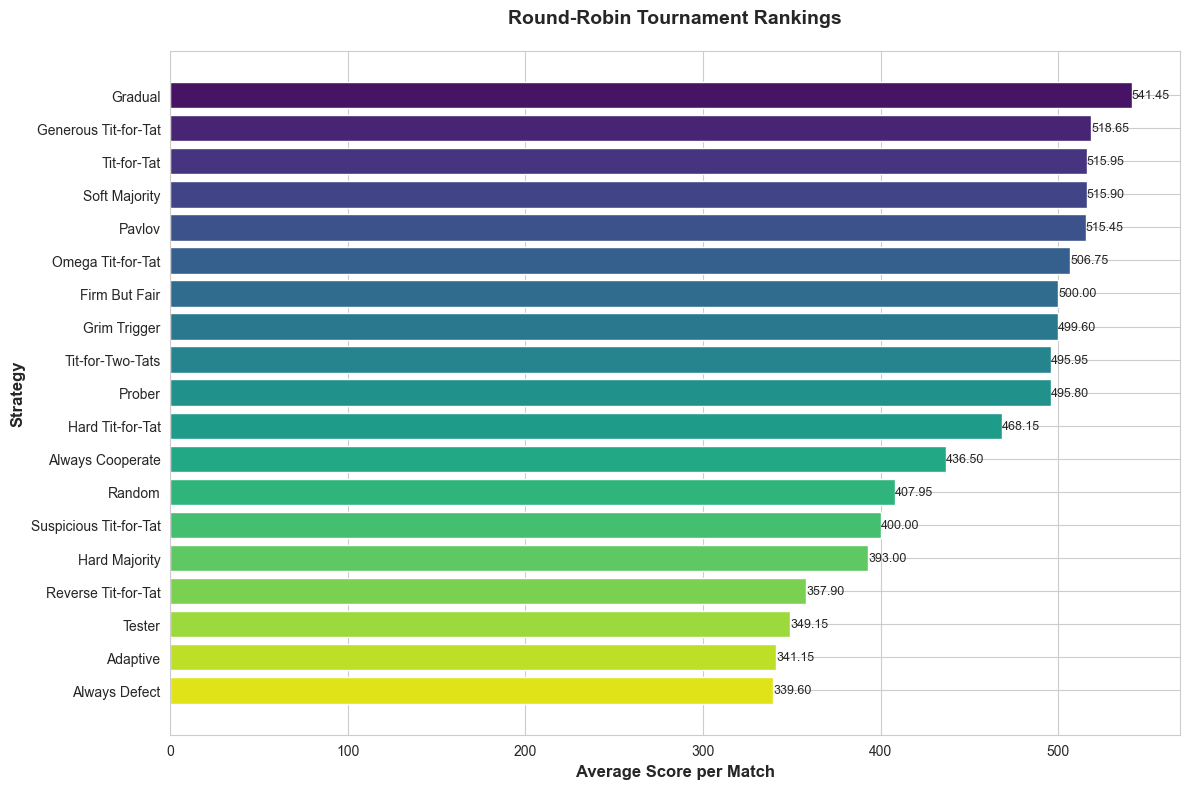

In [30]:
plot_tournament_rankings(rankings, title="Round-Robin Tournament Rankings")

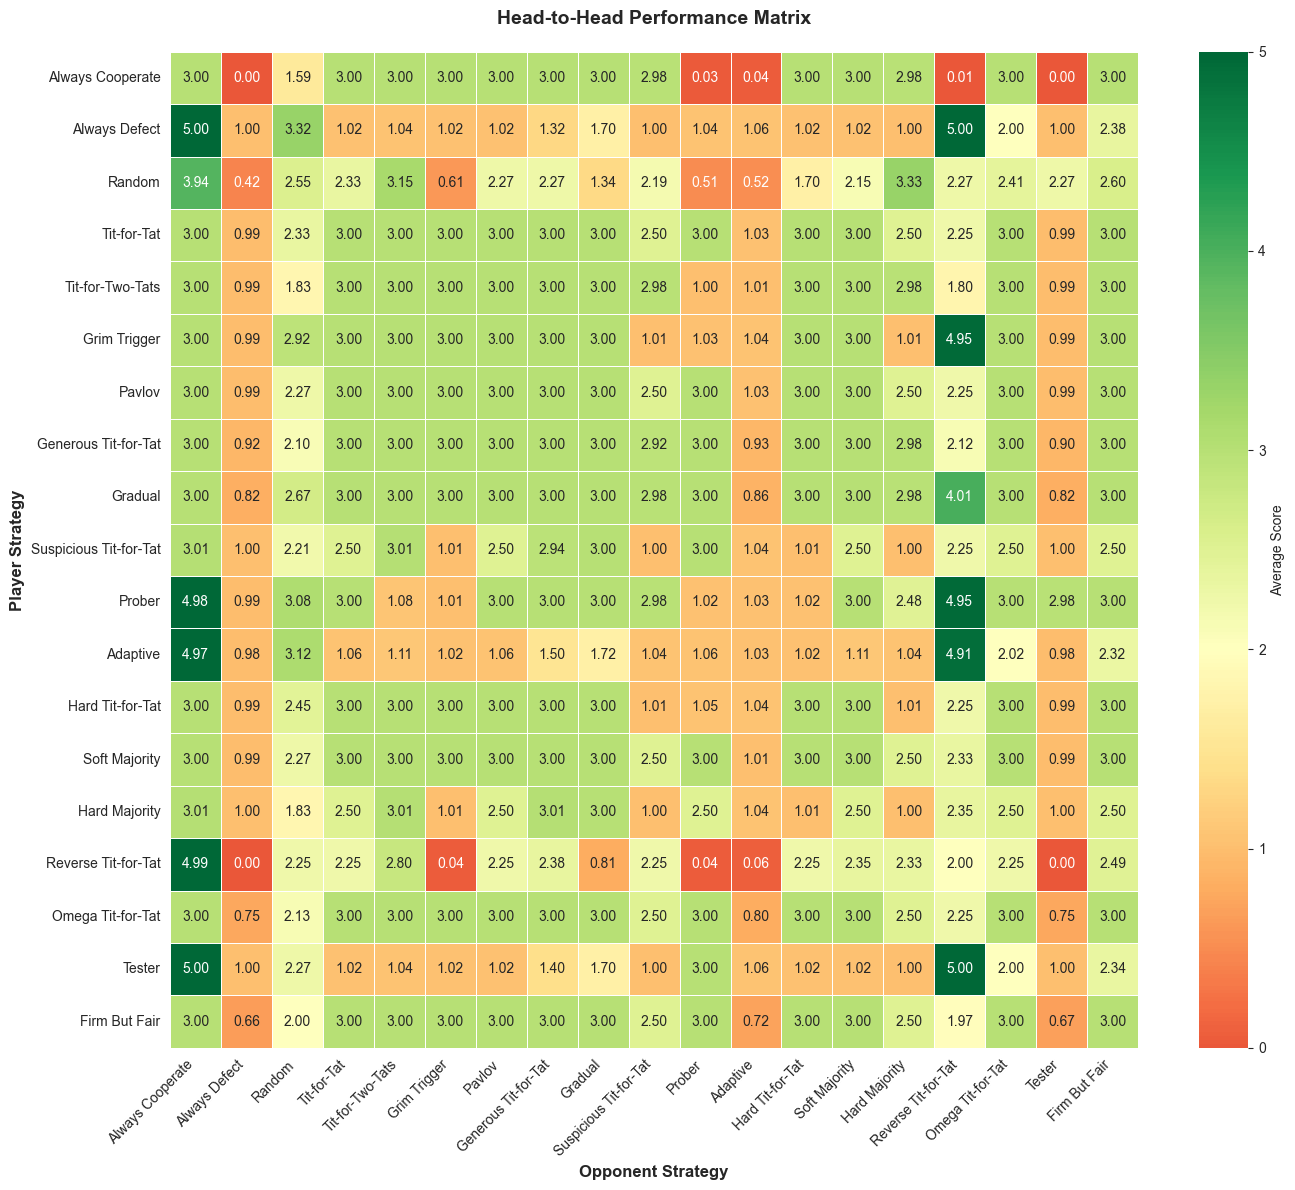

In [31]:
plot_matchup_heatmap(matchup_matrix, title="Head-to-Head Performance Matrix")

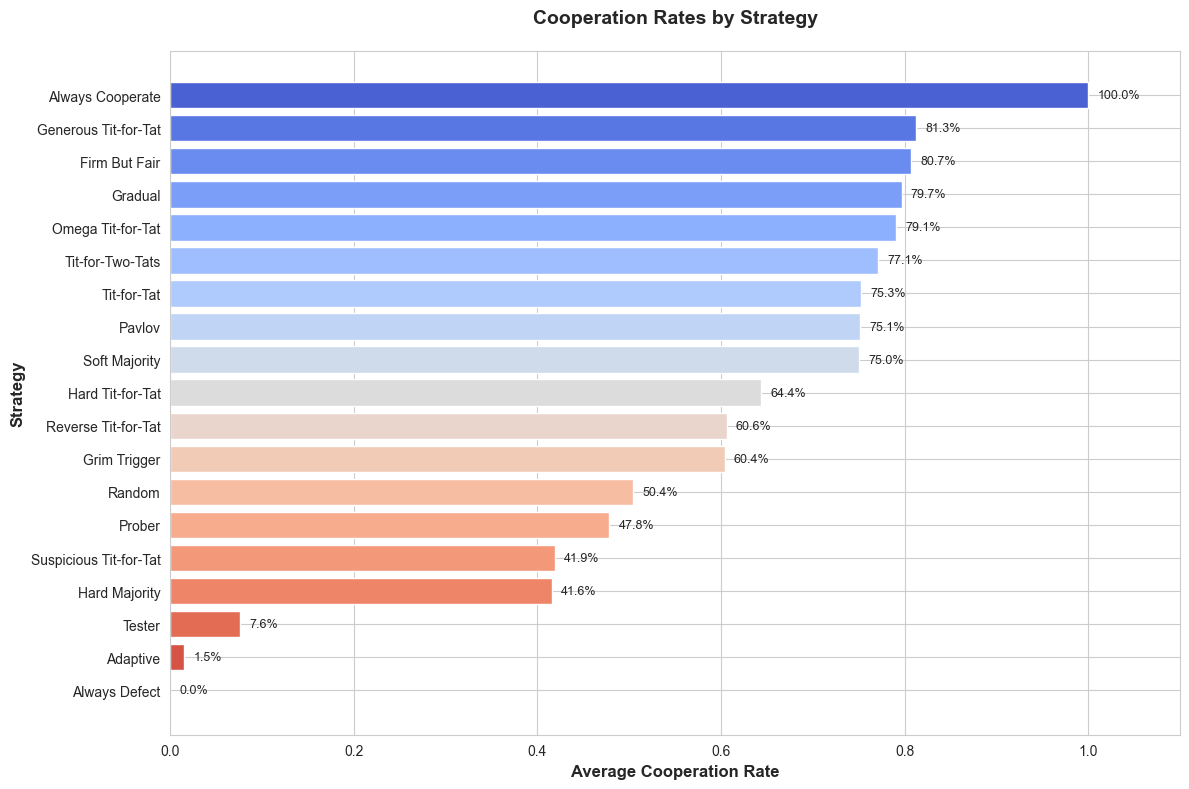

In [32]:
plot_cooperation_rates(tournament.results, title="Cooperation Rates by Strategy")

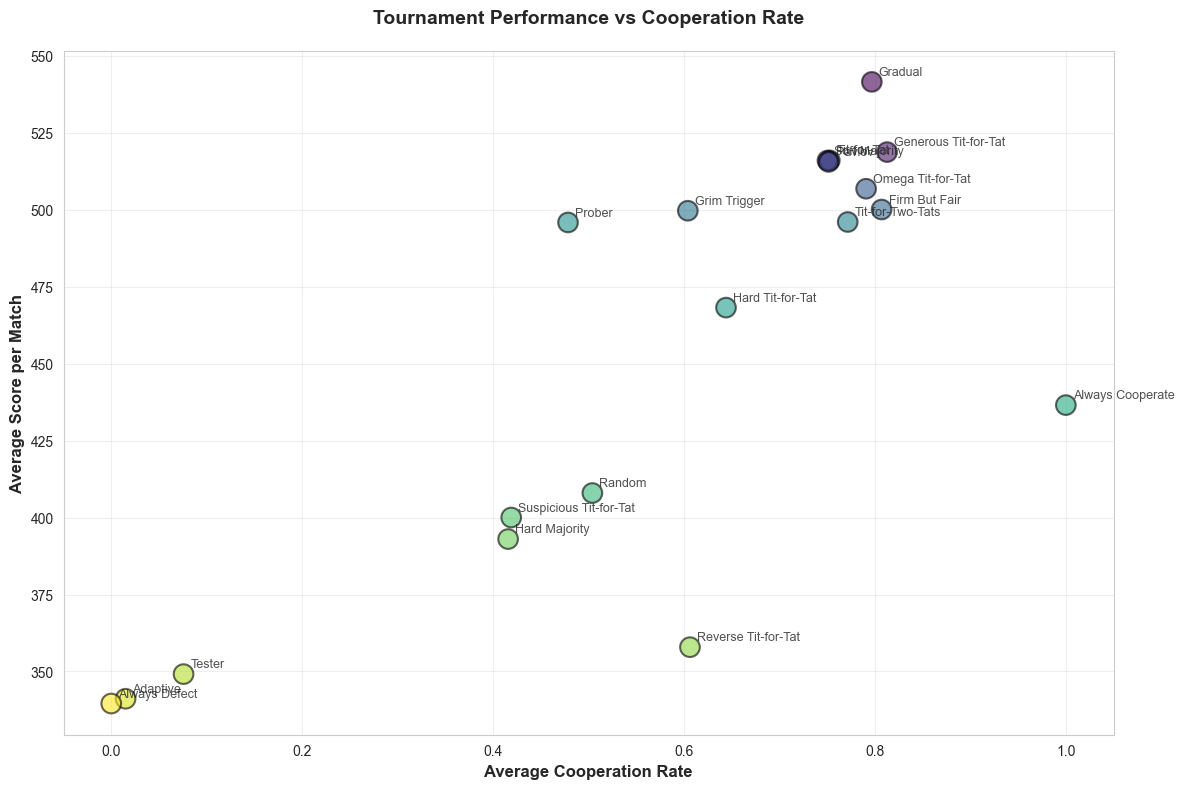

In [33]:
plot_score_vs_cooperation(tournament, title="Tournament Performance vs Cooperation Rate")

### 5.3. Evolutionary Simulation

In this experiment, we simulate evolutionary dynamics using replicator equations. Strategies compete in a population, and those that perform better increase their representation over time.

In [34]:
evolution = EvolutionarySimulation(
    strategies=all_strategies,
    rounds_per_encounter=50,
    initial_population=None  # Equal initial distribution
)

print("Running evolutionary simulation...")
evolution.run_simulation(generations=100, verbose=True)

final_dist = evolution.get_final_distribution()
print("\nFinal Population Distribution:")
print(final_dist.to_string(index=False))

Running evolutionary simulation...
Running evolutionary simulation for 100 generations...

Generation  20: Avg Fitness = 2.981
  Gradual                  : 13.0%
  Generous Tit-for-Tat     : 11.9%
  Soft Majority            : 11.3%

Generation  40: Avg Fitness = 2.998
  Gradual                  : 13.6%
  Generous Tit-for-Tat     : 12.4%
  Soft Majority            : 11.8%

Generation  60: Avg Fitness = 3.000
  Gradual                  : 13.6%
  Generous Tit-for-Tat     : 12.5%
  Soft Majority            : 11.8%

Generation  80: Avg Fitness = 3.000
  Gradual                  : 13.7%
  Generous Tit-for-Tat     : 12.5%
  Soft Majority            : 11.9%

Generation 100: Avg Fitness = 3.000
  Gradual                  : 13.7%
  Generous Tit-for-Tat     : 12.5%
  Soft Majority            : 11.9%

Simulation complete!


Final Population Distribution:
              Strategy  Final Proportion  Final Percentage
               Gradual          0.136660         13.665953
  Generous Tit-for-Tat     

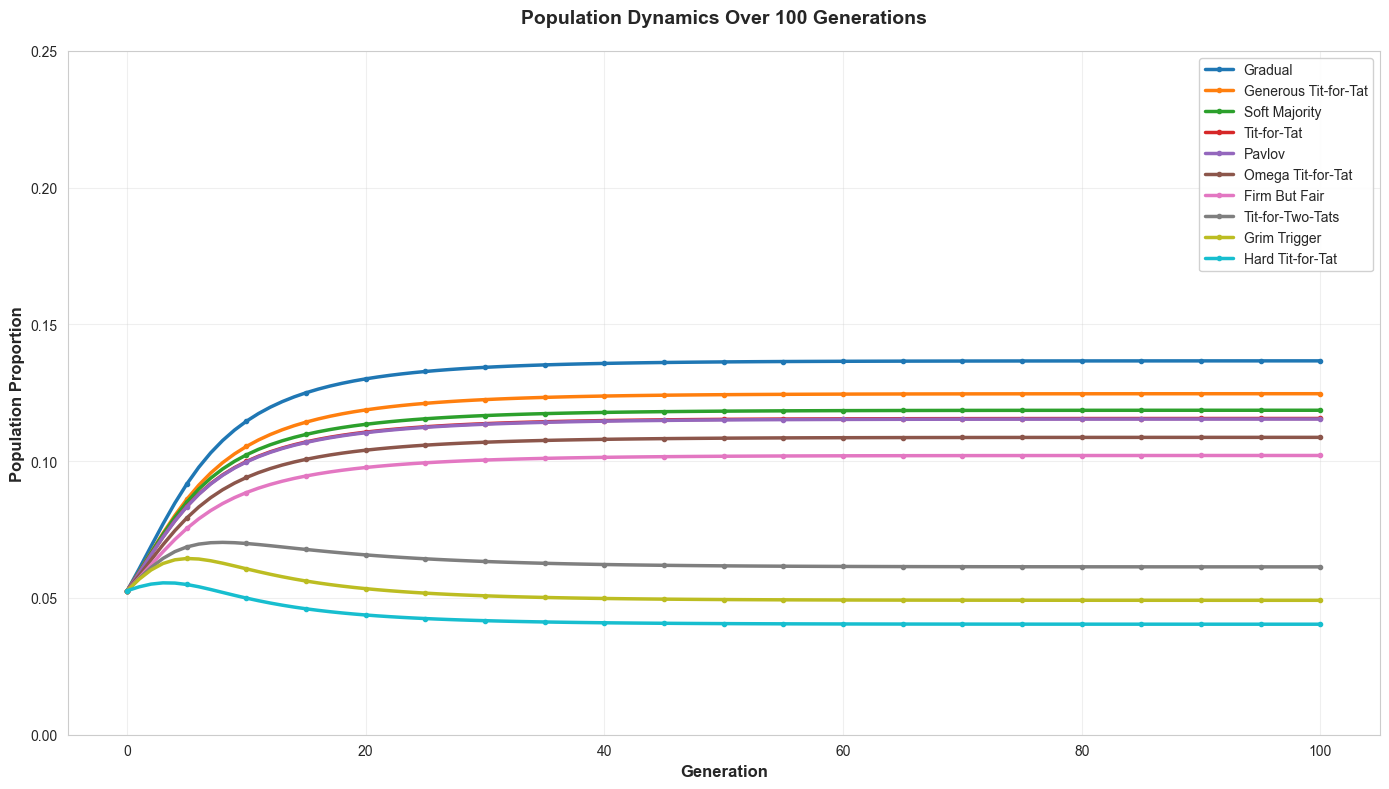

In [35]:
plot_evolutionary_dynamics(evolution, top_n=min(10, N_STRATEGIES), title="Population Dynamics Over 100 Generations", ylim=(0, 0.25))

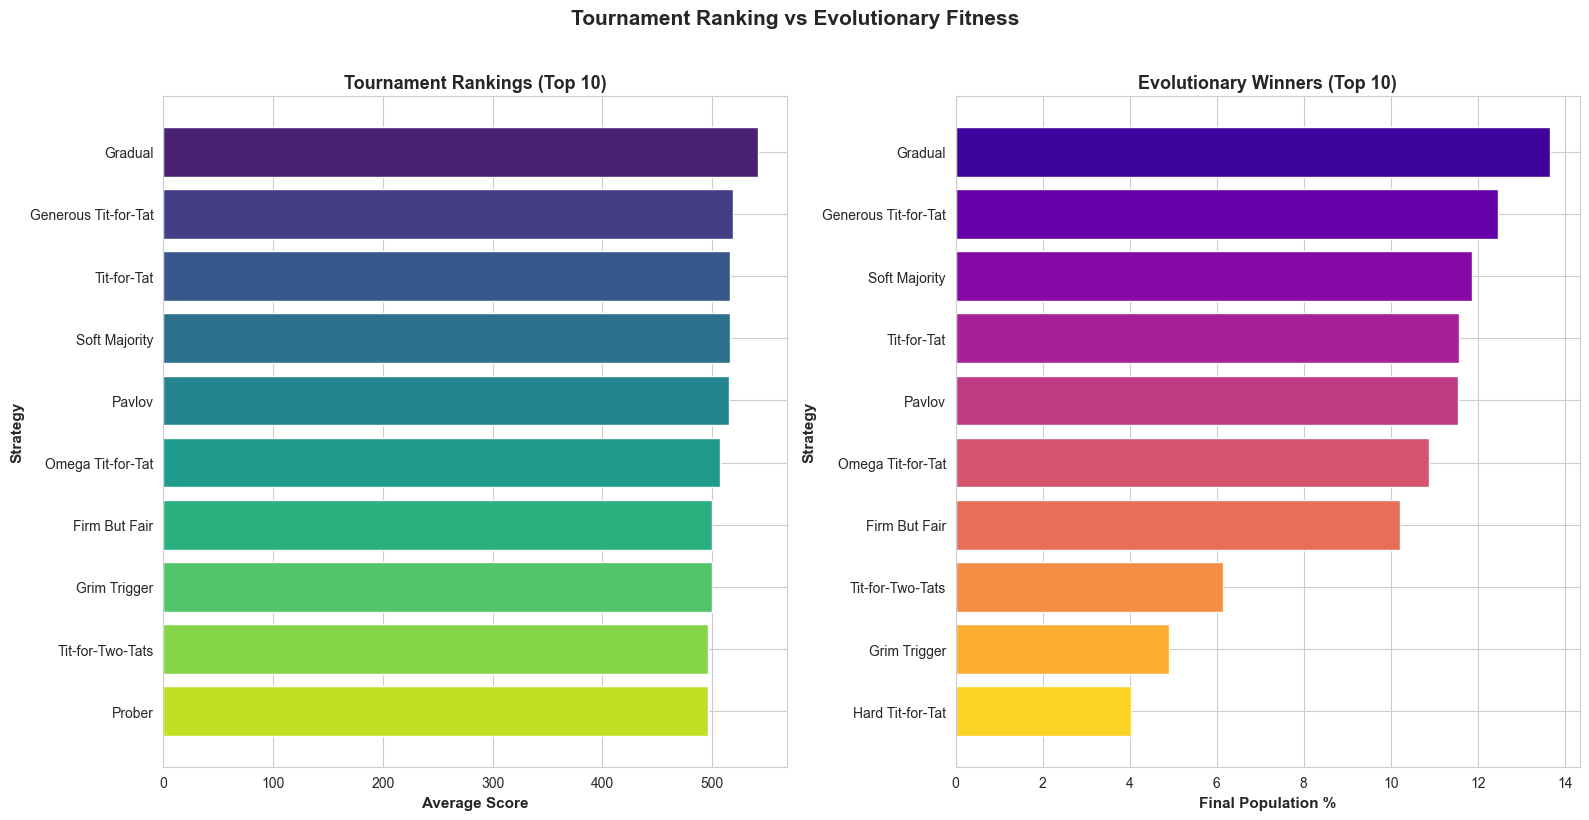

In [36]:
plot_tournament_vs_evolution(rankings, final_dist, 
                              title="Tournament Ranking vs Evolutionary Fitness")

### 5.4. Statistical Analysis

We'll now compute various statistical metrics to understand strategy performance characteristics and identify patterns.

In [37]:
stats = calculate_strategy_statistics(tournament)
print("Strategy Statistics:")
print(stats.to_string(index=False))

coop_corr = compute_cooperation_correlation(stats)
print(f"\n{'='*60}")
print(f"Cooperation-Score Correlation: {coop_corr['correlation']:.3f}")
print(f"{coop_corr['interpretation']}")
print(f"{'='*60}")

robustness = analyze_strategy_robustness(tournament)
print("\nStrategy Robustness Analysis:")
print(robustness.to_string(index=False))

dominant = identify_dominant_strategies(matchup_matrix)
print(f"\nDominant strategies (win >70% of matchups): {dominant}")

esi = calculate_evolutionary_stability_index(evolution)
print("\nEvolutionary Stability Index:")
print(f"Stability Index: {esi:.4f}")
print("(Lower values indicate more stable equilibrium in final generations)")

Strategy Statistics:
              Strategy  Wins  Losses  Ties  Win Rate  Avg Score  Score StdDev  Avg Cooperation
               Gradual     2       5    12  0.105263 538.368421    167.635950         0.786053
  Generous Tit-for-Tat     0       7    12  0.000000 514.368421    153.156683         0.802895
           Tit-for-Tat     0       3    16  0.000000 511.526316    142.911960         0.739737
         Soft Majority     1       4    14  0.052632 511.473684    143.388823         0.737105
                Prober     4       7     8  0.210526 511.157895    241.056286         0.503158
                Pavlov     0       3    16  0.000000 511.000000    143.100627         0.738421
     Omega Tit-for-Tat     0       4    15  0.000000 501.842105    160.401884         0.779737
         Firm But Fair     0       5    14  0.000000 494.736842    168.321385         0.796842
          Grim Trigger     4       2    13  0.210526 494.315789    215.644213         0.583158
      Tit-for-Two-Tats     0 

### 5.5 Execution noise (trembling hand)

In real interactions, intended actions may be executed incorrectly (**trembling hand**). We model this by flipping each player's chosen action from C to D (or vice versa) independently with probability `noise` *after* strategies choose, but *before* payoffs. Histories record **executed** actions, so reciprocal strategies react to what actually occurred on the board.

We compare the same round-robin tournament at noise in `{0, 0.01, 0.05}` with a fixed random seed for reproducibility. The plot at the end of the following cell traces average tournament scores for the five strategies that rank highest at `noise=0`, across the three noise levels.



>>> Running tournament with noise=0.0 ...
Starting tournament with 19 strategies...
Rounds per match: 200
Total matches: 190

Completed 10 matches...
Completed 20 matches...
Completed 30 matches...
Completed 40 matches...
Completed 50 matches...
Completed 60 matches...
Completed 70 matches...
Completed 80 matches...
Completed 90 matches...
Completed 100 matches...
Completed 110 matches...
Completed 120 matches...
Completed 130 matches...
Completed 140 matches...
Completed 150 matches...
Completed 160 matches...
Completed 170 matches...
Completed 180 matches...
Completed 190 matches...

Tournament complete! 190 matches played.


>>> Running tournament with noise=0.01 ...
Starting tournament with 19 strategies...
Rounds per match: 200
Total matches: 190

Completed 10 matches...
Completed 20 matches...
Completed 30 matches...
Completed 40 matches...
Completed 50 matches...
Completed 60 matches...
Completed 70 matches...
Completed 80 matches...
Completed 90 matches...
Completed 100 matche

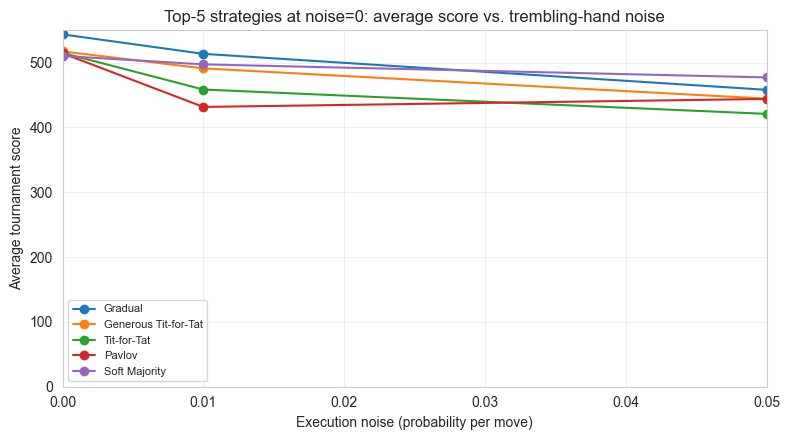

In [38]:
import numpy as np
from ipd.payoffs import DEFAULT_PAYOFFS

noise_levels = [0.0, 0.01, 0.05]
noise_rankings = {}
for nu in noise_levels:
    tnoise = Tournament(
        all_strategies,
        rounds_per_match=200,
        payoff_params=DEFAULT_PAYOFFS,
        noise=nu,
        rng=np.random.default_rng(42),
    )
    print(f"\n>>> Running tournament with noise={nu} ...")
    tnoise.run_tournament()
    noise_rankings[nu] = tnoise.get_rankings()

for nu, df in noise_rankings.items():
    print(f"\n=== Top 10 strategies (noise = {nu}) ===")
    print(df.head(10).to_string())

import matplotlib.pyplot as plt

TOP_K = 5
top_names = noise_rankings[0.0].head(TOP_K)["Strategy"].tolist()
fig, ax = plt.subplots(figsize=(8, 4.5))
for name in top_names:
    scores = []
    for nu in noise_levels:
        rnk = noise_rankings[nu]
        row = rnk[rnk["Strategy"] == name]
        scores.append(float(row["Average Score"].iloc[0]) if len(row) else np.nan)
    ax.plot(noise_levels, scores, marker="o", label=name)
ax.set_xlabel("Execution noise (probability per move)")
ax.set_ylabel("Average tournament score")
ax.set_title(f"Top-{TOP_K} strategies at noise=0: average score vs. trembling-hand noise")
ax.legend(loc="best", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 5.6 Payoff parameter sensitivity

The standard PD inequalities $T > R > P > S$ and $2R > T + S$ allow a range of **temptation** values $T$ while holding $R$, $P$, $S$ fixed. We sweep $T$ and report average tournament scores for **Tit-for-Tat**, **Grim Trigger**, and **Generous Tit-for-Tat** (illustrative reciprocal, punitive, and generous profiles).


Starting tournament with 3 strategies...
Rounds per match: 150
Total matches: 6


Tournament complete! 6 matches played.

Starting tournament with 3 strategies...
Rounds per match: 150
Total matches: 6


Tournament complete! 6 matches played.

Starting tournament with 3 strategies...
Rounds per match: 150
Total matches: 6


Tournament complete! 6 matches played.

Starting tournament with 3 strategies...
Rounds per match: 150
Total matches: 6


Tournament complete! 6 matches played.

Starting tournament with 3 strategies...
Rounds per match: 150
Total matches: 6


Tournament complete! 6 matches played.

Starting tournament with 3 strategies...
Rounds per match: 150
Total matches: 6


Tournament complete! 6 matches played.

Starting tournament with 3 strategies...
Rounds per match: 150
Total matches: 6


Tournament complete! 6 matches played.

Starting tournament with 3 strategies...
Rounds per match: 150
Total matches: 6


Tournament complete! 6 matches played.

       T  Tit-for-Tat  G

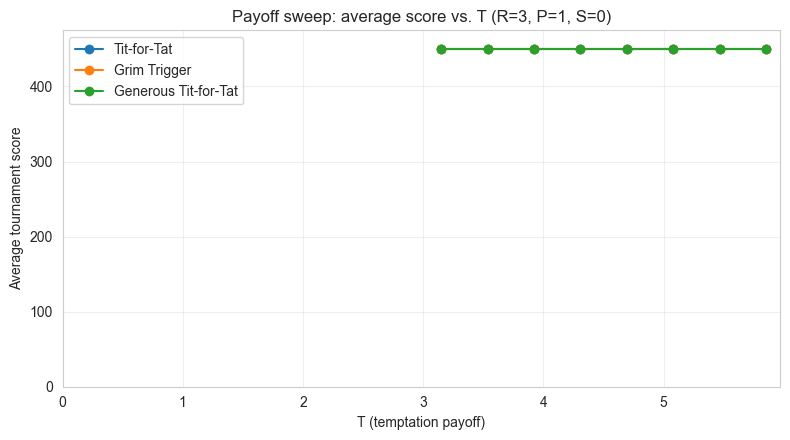

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ipd.payoffs import PayoffParams

R, P, S = 3.0, 1.0, 0.0
T_grid = np.linspace(3.15, 5.85, 8)

labels = ["Tit-for-Tat", "Grim Trigger", "Generous Tit-for-Tat"]
name_to_cls = {
    "Tit-for-Tat": TitForTat,
    "Grim Trigger": Grim,
    "Generous Tit-for-Tat": GenerousTitForTat,
}
triple = [name_to_cls[name]() for name in labels]

rows = []
for T in T_grid:
    pp = PayoffParams(T=float(T), R=R, P=P, S=S)
    ts = Tournament(
        triple,
        rounds_per_match=150,
        payoff_params=pp,
        noise=0.0,
        rng=np.random.default_rng(123),
    )
    ts.run_tournament()
    rnk = ts.get_rankings().set_index("Strategy")["Average Score"]
    row = {"T": T}
    for lab in labels:
        row[lab] = rnk.get(lab, float("nan"))
    rows.append(row)

sweep_df = pd.DataFrame(rows)
print(sweep_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.5))
for lab in labels:
    ax.plot(sweep_df["T"], sweep_df[lab], marker="o", label=lab)
ax.set_xlabel("T (temptation payoff)")
ax.set_ylabel("Average tournament score")
ax.set_title("Payoff sweep: average score vs. T (R=3, P=1, S=0)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Conclusions and Discussion

### 6.1 Summary of Empirical Findings

**Tournament Results**

The round-robin tournament with 19 strategies and 200 rounds per match shows:
- **Top performers:** Generous Tit-for-Tat, Gradual, Tit-for-Tat, Soft Majority, and Pavlov achieve the highest average scores.
- **Bottom performers:** Always Defect, Adaptive, and Random rank lowest.
- **Pure strategies:** Always Cooperate and Always Defect underperform compared to conditional strategies.

These tournament bullets summarize the **baseline** run in Section 5.2 (default payoffs, **zero execution noise**). Section 5.5 shows that with trembling-hand noise, **rankings** can reshuffle (e.g. different leaders at higher noise), but the broad **pattern** is unchanged: reciprocal, generous, and majority-type rules still outperform Always Defect and Random; we do not see unconditional defection become the best-performing rule.

**Evolutionary Dynamics**

The evolutionary simulation (100 generations, equal initial population) demonstrates:
- **Cooperative strategies dominate:** Several reciprocal and generous strategies (e.g. Gradual, Generous Tit-for-Tat, Soft Majority, Pavlov, Tit-for-Tat, Grim Trigger) take the largest shares at equilibrium; exact shares depend on the number of strategies in the pool.
- **Lower proportions:** Tit-for-Two-Tats and Always Cooperate stabilize at lower levels (~7–8%).
- **Extinction:** Always Defect, Adaptive, Random, Prober, and similar strategies decline to near zero.
- **Stability:** The Evolutionary Stability Index ≈ 0 indicates a stable equilibrium in the final generations.

**Cooperation vs. Success**

- **Correlation:** Strong positive correlation between cooperation rate and average score (see the printed value in the statistical analysis output).
- **Interpretation:** More cooperative strategies tend to score higher.
- **Pattern:** Pure cooperation (100%) is exploitable; conditional cooperation (≈60–90%) performs best.

**Robustness**

- **Most robust:** Tit-for-Tat, Soft Majority, Pavlov (lowest coefficient of variation).
- **Least robust:** Always Defect, Adaptive (highest variance across opponents).

---

### 6.2 Answers to Research Questions

1. **Which strategies succeed in round-robin tournaments?** In the baseline tournament (Section 5.2), reciprocal strategies (Tit-for-Tat, Generous Tit-for-Tat, Pavlov, Gradual) rank highest, confirming Axelrod's findings. Section 5.5 shows that **rankings** are sensitive to execution noise, without overturning this qualitative picture.

2. **What is the optimal balance between cooperation and retaliation?** Pure strategies underperform. The best strategies combine: nice (start with cooperation), retaliatory (punish defection), and forgiving (return to cooperation).

3. **How does cooperation evolve in populations over time?** Cooperative strategies dominate; Always Defect and similar strategies are driven out.

4. **Why does iteration fundamentally change rational behavior?** Iteration introduces the shadow of the future—reputation and reciprocity matter. Players can punish defection and reward cooperation over time, making cooperation rational when the discount factor δ is sufficiently high. The Folk Theorem shows that mutual cooperation can be sustained as a Nash equilibrium in repeated games, unlike the one-shot game where defection is dominant.

---

### 6.3 Limitations and Assumptions

- **Fixed payoff matrix:** We use T=5, R=3, P=1, S=0; different values could alter results.
- **Noise and payoff extensions:** Sections 5.5–5.6 report trembling-hand noise and a sweep over the temptation parameter $T$. The main experiments in sections 5.1–5.4 use **zero noise** and the default matrix $T=5$, $R=3$, $P=1$, $S=0$ unless stated.
- **Finite rounds:** 200 rounds per match; infinite or probabilistic horizons could change dynamics.
- **Strategy set:** We use 19 representative strategies; the full IPD strategy space is still vast (e.g., Zero-Determinant strategies).
- **Well-mixed population:** No spatial or network structure; all strategies interact equally.